<a href="https://colab.research.google.com/github/dee431/House-Price-Prediction-Using-Linear-Regression/blob/main/Copy_of_House_Price_Prediction_Using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**📌 Cell 1 — Project Title**

In [ ]:
# ==========================================
# House Price Prediction using Linear Regression
# Internship Project
# Developed by: Your Name
# ==========================================

**📌📌 Cell 2 — Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

**📌 Cell 3 — Load Dataset**

In [ ]:
df = pd.read_csv("/content/Housing-selected-columns.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes


**📌 Cell 5 — Dataset Information**

In [ ]:
print(df.shape)

df.info()

(545, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   mainroad         545 non-null    object
 6   guestroom        545 non-null    object
 7   basement         545 non-null    object
 8   hotwaterheating  545 non-null    object
 9   airconditioning  545 non-null    object
dtypes: int64(5), object(5)
memory usage: 42.7+ KB


**📌 Cell 6 — Statistical Summary**

In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000


**📌 Cell 7 — Check Missing Values**

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


**📌 Cell 8 — Check Duplicate Rows**

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


**📌 Cell 9 — Data Visualization (House Price Distribution)**

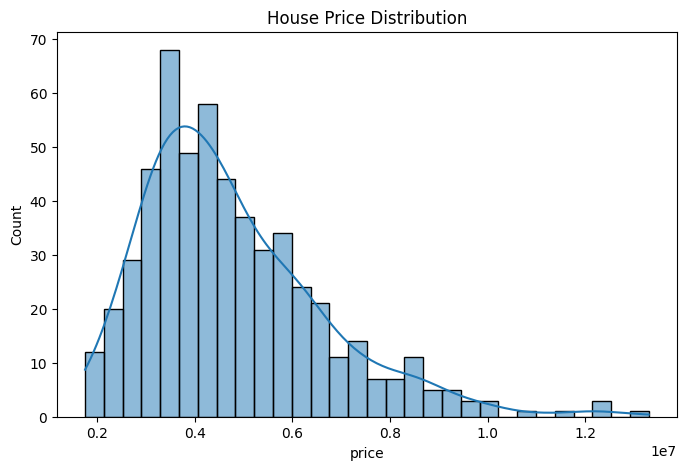

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("House Price Distribution")
plt.show()

**📌 Cell 10 — Correlation Heatmap**

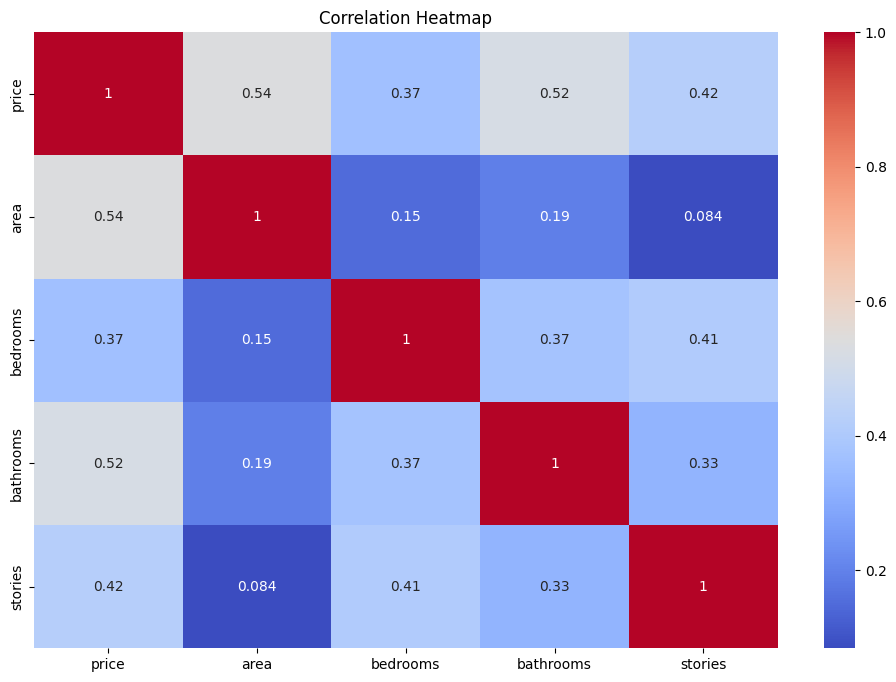

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

**📌 Cell 11 — Scatter Plot (Area vs Price)**

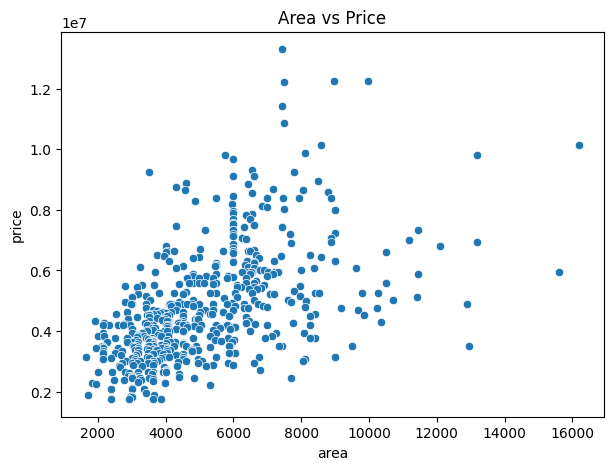

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(x=df["area"],
                y=df["price"])

plt.title("Area vs Price")

plt.show()

**📌 Cell 12 — Boxplot**

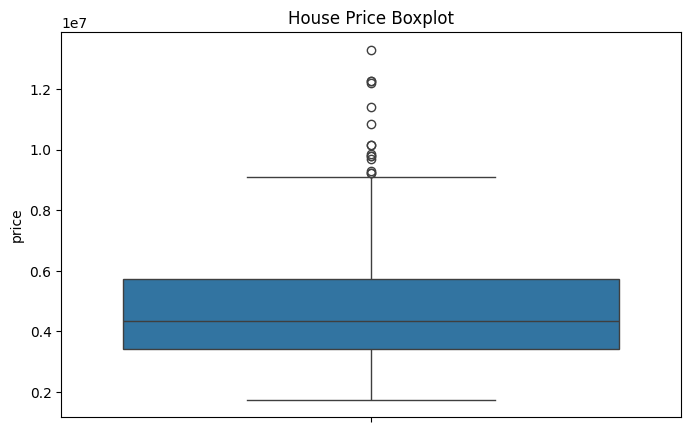

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(df["price"])

plt.title("House Price Boxplot")

plt.show()

**📌 Cell 13 — Encode Categorical Columns**

In [ ]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,1,0,0,0,1
1,12250000,8960,4,4,4,1,0,0,0,1
2,12250000,9960,3,2,2,1,0,1,0,0
3,12215000,7500,4,2,2,1,0,1,0,1
4,11410000,7420,4,1,2,1,1,1,0,1


**📌 Cell 14 — Feature Selection**

In [ ]:
X = df.drop("price", axis=1)

y = df["price"]

**📌 Cell 15 — Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape)

print("Testing Samples:", X_test.shape)

Training Samples: (436, 9)
Testing Samples: (109, 9)


**📌 Cell 16 — Train Linear Regression Model**

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


**📌 Cell 17 — Model Coefficients**

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,area,2.800897e+02
1,bedrooms,1.189729e+05
2,bathrooms,1.119867e+06
3,stories,4.029370e+05
4,mainroad,6.127039e+05
5,guestroom,2.575018e+05
6,basement,5.374749e+05
7,hotwaterheating,7.307012e+05
8,airconditioning,8.743500e+05


**📌 Cell 18 — Prediction**

In [ ]:
y_pred = model.predict(X_test)

y_pred[:10]

array([5416967.08149047, 6818564.06211807, 3210479.195361  ,
       4875625.14092177, 3307044.88314089, 4080092.39283054,
       5458603.83431915, 6032291.13442084, 2631205.31786445,
       2341427.99211515])

**📌 Cell 19 — Model Evaluation**

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)

Mean Absolute Error : 1029305.7135858475
Mean Squared Error : 1997147293758.538
Root Mean Squared Error : 1413204.618503116
R2 Score : 0.6048828690833074


**📌 Cell 20 — Actual vs Predicted**

In [ ]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head(15)

,Actual Price,Predicted Price
316,4060000,5.416967e+06
77,6650000,6.818564e+06
360,3710000,3.210479e+06
90,6440000,4.875625e+06
493,2800000,3.307045e+06
209,4900000,4.080092e+06
176,5250000,5.458604e+06
249,4543000,6.032291e+06
516,2450000,2.631205e+06
426,3353000,2.341428e+06


**📌 Cell 21 — Scatter Plot (Actual vs Predicted)**

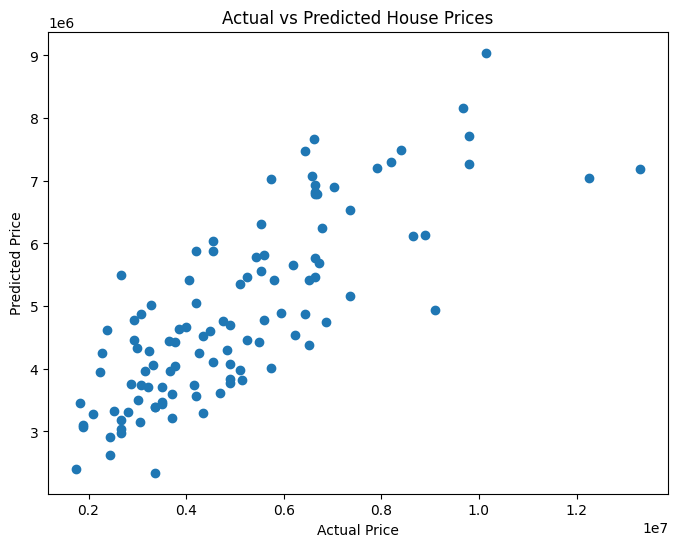

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

**📌 Cell 22 — Residual Plot**

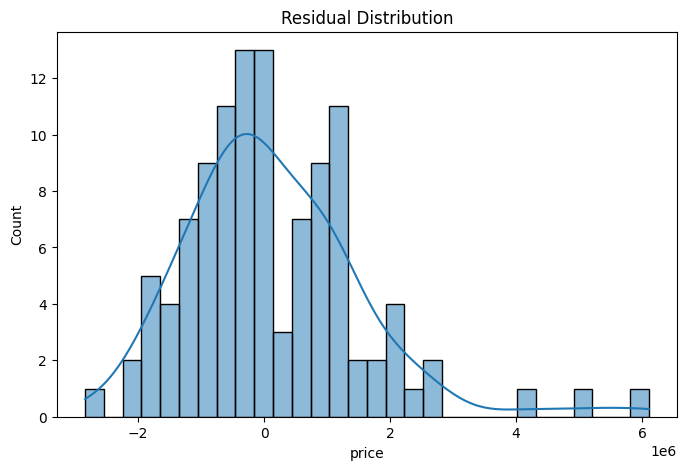

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals,
             bins=30,
             kde=True)

plt.title("Residual Distribution")

plt.show()

**📌 Cell 23 — Predict New House Price**

In [ ]:
sample_house = [[
    6500,   # area
    3,      # bedrooms
    2,      # bathrooms
    2,      # stories
    1,      # mainroad
    0,      # guestroom
    1,      # basement
    0,      # hotwaterheating
    1       # airconditioning
]]

prediction = model.predict(sample_house)

print("Predicted House Price:", prediction[0])

Predicted House Price: 6953101.945568516


**📌 Cell 24 — Save Model**

In [ ]:
import joblib

joblib.dump(model, "HousePricePredictionModel.pkl")

print("Model Saved Successfully")

Model Saved Successfully


**📌 Cell 25 — Load Saved Model**

In [ ]:
loaded_model = joblib.load("HousePricePredictionModel.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


**📌 Cell 26 — Download Model**

In [ ]:
from google.colab import files

files.download("HousePricePredictionModel.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>